# Prophet Forecasting

This notebook evaluates Prophet as a demand forecasting model for the `FOODS`, `HOBBIES`, and `HOUSEHOLD` categories.

Prophet is designed to model trend and seasonality. It will use the same 13 expanding monthly validation windows as the baseline and Linear Regression notebooks, so results remain comparable.

Main objectives:

1. Fit Prophet models for each category and validation window.
2. Include weekly and yearly seasonality.
3. Include Christmas as a holiday effect.
4. Test a small number of understandable parameter combinations.
5. Select the best Prophet setup using validation WAPE and stability.
6. Save the selected setup and validation results for the final comparison.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

import models_metrics

In [2]:
train_data = pd.read_parquet(
    "data/processed/train_data.parquet"
)

validation_data = pd.read_parquet(
    "data/processed/validation_data.parquet"
)

validation_windows = pd.read_parquet(
    "data/processed/validation_windows.parquet"
)

In [3]:
development_data = pd.concat(
    [train_data, validation_data],
    ignore_index=True,
)

development_daily = (
    development_data
    .groupby(
        ["cat_id", "ds"],
        observed=True,
        as_index=False,
    )
    .agg(y=("y", "sum"))
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)

development_daily

,cat_id,ds,y
0,HOBBIES,2011-01-29,3764.0
1,HOBBIES,2011-01-30,3357.0
2,HOBBIES,2011-01-31,2682.0
3,HOBBIES,2011-02-01,2669.0
4,HOBBIES,2011-02-02,1814.0
...,...,...,...
4807,FOODS,2015-06-16,21346.0
4808,FOODS,2015-06-17,20254.0
4809,FOODS,2015-06-18,22419.0
4810,FOODS,2015-06-19,24540.0


In [4]:
christmas_holidays = pd.DataFrame(
    {
        "holiday": "christmas",
        "ds": pd.to_datetime(
            [
                "2011-12-25",
                "2012-12-25",
                "2013-12-25",
                "2014-12-25",
                "2015-12-25",
            ]
        ),
        "lower_window": 0,
        "upper_window": 0,
    }
)

christmas_holidays

,holiday,ds,lower_window,upper_window
0,christmas,2011-12-25,0,0
1,christmas,2012-12-25,0,0
2,christmas,2013-12-25,0,0
3,christmas,2014-12-25,0,0
4,christmas,2015-12-25,0,0


In [5]:
category = "FOODS"

window = validation_windows.iloc[0]

train = development_daily[
    (development_daily["cat_id"] == category)
    & (development_daily["ds"] <= window["train_end"])
].copy()

validation = development_daily[
    (development_daily["cat_id"] == category)
    & (development_daily["ds"] >= window["validation_start"])
    & (development_daily["ds"] <= window["validation_end"])
].copy()

print(
    f"{category} | "
    f"{window['validation_start'].date()} to "
    f"{window['validation_end'].date()} | "
    f"{len(validation)} forecast days"
)

FOODS | 2014-06-21 to 2014-06-30 | 10 forecast days


In [6]:
prophet_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=christmas_holidays,
)

prophet_model.fit(
    train[["ds", "y"]]
)

02:12:07 - cmdstanpy - INFO - Chain [1] start processing


02:12:07 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
future_dates = validation[["ds"]].copy()

prophet_forecast = prophet_model.predict(
    future_dates
)

forecast = prophet_forecast["yhat"].clip(
    lower=0
).to_numpy()

forecast

array([31414.41248215, 31550.84968964, 26083.5000886 , 24547.84762328,
       24191.98119991, 24302.6577534 , 26760.22229956, 31412.15092705,
       31503.6728641 , 25995.26802044])

In [8]:
first_prophet_metrics = (
    models_metrics.calculate_validation_metrics(
        actual=validation["y"],
        forecast=forecast,
    )
)

first_prophet_metrics

{'MAE': np.float64(3750.3562948118424),
 'RMSE': np.float64(3835.8754378701674),
 'WAPE (%)': np.float64(15.609639159456428)}

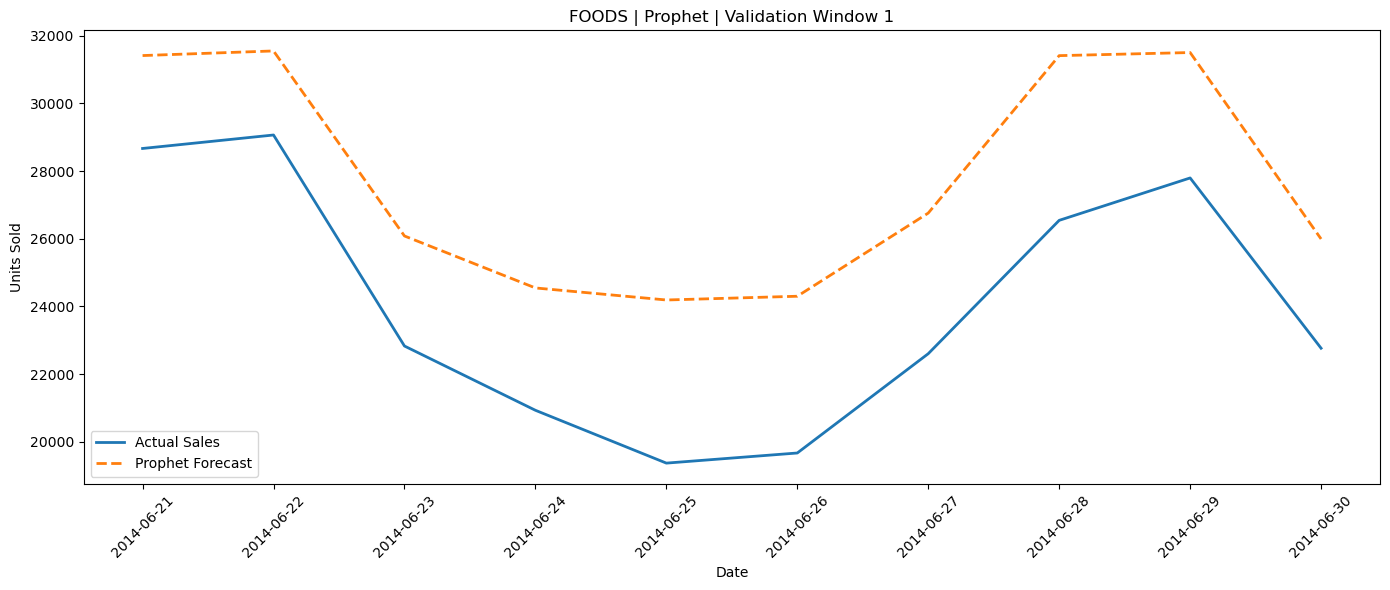

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation["ds"],
    validation["y"],
    label="Actual Sales",
    linewidth=2,
)

plt.plot(
    validation["ds"],
    forecast,
    label="Prophet Forecast",
    linestyle="--",
    linewidth=2,
)

plt.title(
    f"{category} | Prophet | "
    f"Validation Window {int(window['window'])}"
)
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
prophet_metric_records = []
prophet_forecast_records = []

for category in development_daily["cat_id"].unique():

    category_data = development_daily[
        development_daily["cat_id"] == category
    ].copy()

    for _, window in validation_windows.iterrows():

        train = category_data[
            category_data["ds"] <= window["train_end"]
        ].copy()

        validation = category_data[
            (category_data["ds"] >= window["validation_start"])
            & (category_data["ds"] <= window["validation_end"])
        ].copy()

        print(
            f"{category} | "
            f"Window {int(window['window'])} | "
            f"{len(validation)} forecast days"
        )

        prophet_model = Prophet(
            weekly_seasonality=True,
            yearly_seasonality=True,
            holidays=christmas_holidays,
        )

        prophet_model.fit(
            train[["ds", "y"]]
        )

        prophet_forecast = prophet_model.predict(
            validation[["ds"]]
        )

        forecast = prophet_forecast["yhat"].clip(
            lower=0
        ).to_numpy()

        metrics = (
            models_metrics.calculate_validation_metrics(
                actual=validation["y"],
                forecast=forecast,
            )
        )

        prophet_metric_records.append(
            {
                "cat_id": category,
                "window": int(window["window"]),
                "train_end": window["train_end"],
                "validation_start": window["validation_start"],
                "validation_end": window["validation_end"],
                "forecast_days": len(validation),
                "Model": "Prophet (Default)",
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "WAPE (%)": metrics["WAPE (%)"],
            }
        )

        for date, actual_value, forecast_value in zip(
            validation["ds"],
            validation["y"],
            forecast,
        ):
            prophet_forecast_records.append(
                {
                    "cat_id": category,
                    "window": int(window["window"]),
                    "ds": date,
                    "Model": "Prophet (Default)",
                    "actual": actual_value,
                    "forecast": forecast_value,
                }
            )

02:12:07 - cmdstanpy - INFO - Chain [1] start processing


02:12:07 - cmdstanpy - INFO - Chain [1] done processing


HOBBIES | Window 1 | 10 forecast days
HOBBIES | Window 2 | 31 forecast days


02:12:07 - cmdstanpy - INFO - Chain [1] start processing


02:12:07 - cmdstanpy - INFO - Chain [1] done processing


...

02:12:14 - cmdstanpy - INFO - Chain [1] start processing


02:12:14 - cmdstanpy - INFO - Chain [1] done processing


FOODS | Window 12 | 31 forecast days
FOODS | Window 13 | 20 forecast days


02:12:14 - cmdstanpy - INFO - Chain [1] start processing


02:12:14 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
prophet_metrics = pd.DataFrame(
    prophet_metric_records
)

prophet_forecasts = pd.DataFrame(
    prophet_forecast_records
)

prophet_metrics.groupby(
    ["cat_id", "Model"],
    observed=True,
)["window"].nunique()

cat_id     Model            
FOODS      Prophet (Default)    13
HOBBIES    Prophet (Default)    13
HOUSEHOLD  Prophet (Default)    13
Name: window, dtype: int64

In [12]:
prophet_summary = (
    prophet_metrics
    .groupby(
        ["cat_id", "Model"],
        observed=True,
        as_index=False,
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_WAPE=("WAPE (%)", "mean"),
        Std_WAPE=("WAPE (%)", "std"),
        Best_WAPE=("WAPE (%)", "min"),
        Worst_WAPE=("WAPE (%)", "max"),
    )
    .round(2)
)

prophet_summary

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Prophet (Default),2226.81,2679.09,9.15,2.53,5.61,15.61
1,HOBBIES,Prophet (Default),259.03,328.16,7.59,2.30,3.92,10.90
2,HOUSEHOLD,Prophet (Default),592.83,782.33,7.02,2.14,3.71,11.36


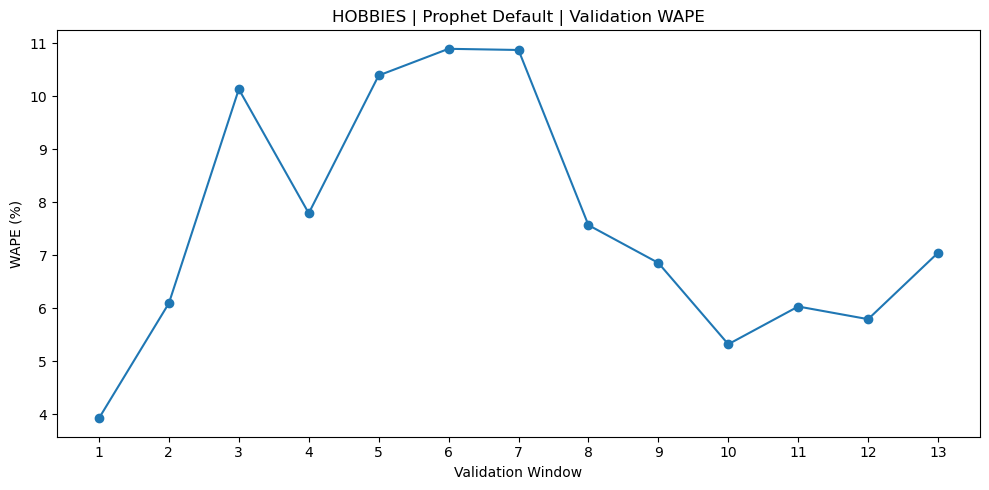

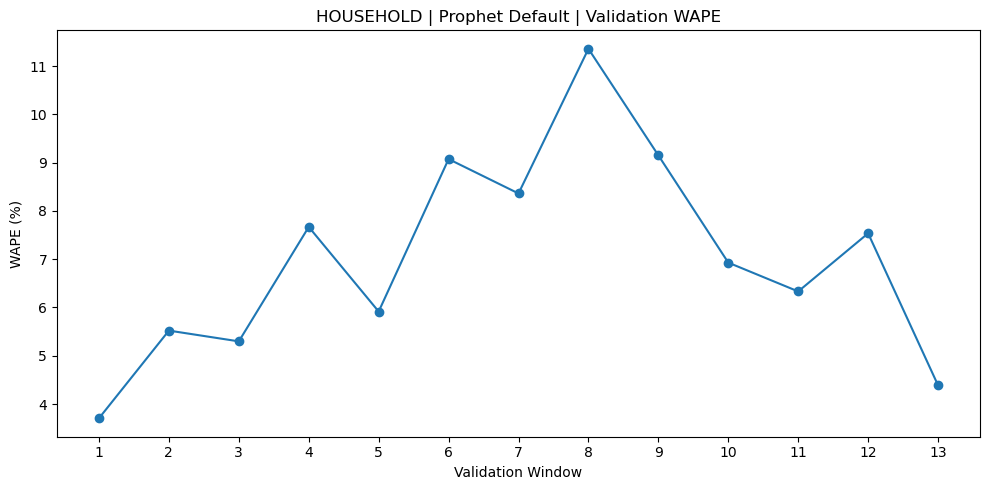

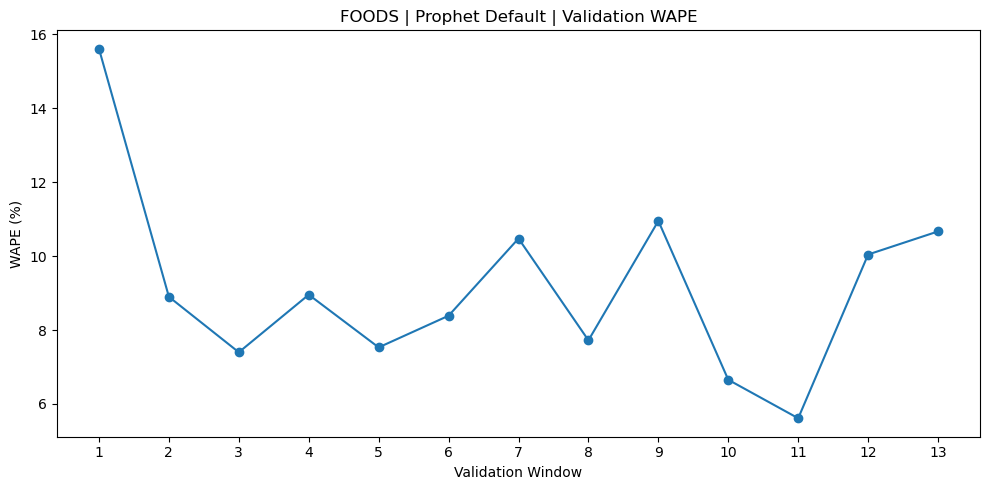

In [13]:
for category in prophet_metrics["cat_id"].unique():

    plot_data = prophet_metrics[
        prophet_metrics["cat_id"] == category
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(
        plot_data["window"],
        plot_data["WAPE (%)"],
        marker="o",
    )

    plt.title(
        f"{category} | Prophet Default | Validation WAPE"
    )
    plt.xlabel("Validation Window")
    plt.ylabel("WAPE (%)")
    plt.xticks(plot_data["window"])
    plt.tight_layout()
    plt.show()

In [14]:
prophet_settings = [
    {
        "name": "Prophet Additive",
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
    },
    {
        "name": "Prophet Conservative",
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.01,
    },
    {
        "name": "Prophet Flexible",
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.10,
    },
    {
        "name": "Prophet Multiplicative",
        "seasonality_mode": "multiplicative",
        "changepoint_prior_scale": 0.05,
    },
]

In [15]:
prophet_tuning_metric_records = []
prophet_tuning_forecast_records = []

for category in development_daily["cat_id"].unique():

    category_data = development_daily[
        development_daily["cat_id"] == category
    ].copy()

    for setting in prophet_settings:

        for _, window in validation_windows.iterrows():

            train = category_data[
                category_data["ds"] <= window["train_end"]
            ].copy()

            validation = category_data[
                (category_data["ds"] >= window["validation_start"])
                & (category_data["ds"] <= window["validation_end"])
            ].copy()

            print(
                f"{category} | "
                f"{setting['name']} | "
                f"Window {int(window['window'])}"
            )

            prophet_model = Prophet(
                weekly_seasonality=True,
                yearly_seasonality=True,
                holidays=christmas_holidays,
                seasonality_mode=setting["seasonality_mode"],
                changepoint_prior_scale=setting[
                    "changepoint_prior_scale"
                ],
            )

            prophet_model.fit(
                train[["ds", "y"]]
            )

            prophet_forecast = prophet_model.predict(
                validation[["ds"]]
            )

            forecast = prophet_forecast["yhat"].clip(
                lower=0
            ).to_numpy()

            metrics = (
                models_metrics.calculate_validation_metrics(
                    actual=validation["y"],
                    forecast=forecast,
                )
            )

            prophet_tuning_metric_records.append(
                {
                    "cat_id": category,
                    "window": int(window["window"]),
                    "Model": setting["name"],
                    "MAE": metrics["MAE"],
                    "RMSE": metrics["RMSE"],
                    "WAPE (%)": metrics["WAPE (%)"],
                }
            )

            for date, actual_value, forecast_value in zip(
                validation["ds"],
                validation["y"],
                forecast,
            ):
                prophet_tuning_forecast_records.append(
                    {
                        "cat_id": category,
                        "window": int(window["window"]),
                        "ds": date,
                        "Model": setting["name"],
                        "actual": actual_value,
                        "forecast": forecast_value,
                    }
                )

02:12:15 - cmdstanpy - INFO - Chain [1] start processing


02:12:15 - cmdstanpy - INFO - Chain [1] done processing


HOBBIES | Prophet Additive | Window 1
HOBBIES | Prophet Additive | Window 2


02:12:15 - cmdstanpy - INFO - Chain [1] start processing


02:12:15 - cmdstanpy - INFO - Chain [1] done processing


...

02:12:43 - cmdstanpy - INFO - Chain [1] start processing


02:12:43 - cmdstanpy - INFO - Chain [1] done processing


02:12:43 - cmdstanpy - INFO - Chain [1] start processing


FOODS | Prophet Multiplicative | Window 13


02:12:43 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
prophet_tuning_metrics = pd.DataFrame(
    prophet_tuning_metric_records
)

prophet_tuning_forecasts = pd.DataFrame(
    prophet_tuning_forecast_records
)

prophet_tuning_summary = (
    prophet_tuning_metrics
    .groupby(
        ["cat_id", "Model"],
        observed=True,
        as_index=False,
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_WAPE=("WAPE (%)", "mean"),
        Std_WAPE=("WAPE (%)", "std"),
        Best_WAPE=("WAPE (%)", "min"),
        Worst_WAPE=("WAPE (%)", "max"),
    )
    .round(2)
)

prophet_tuning_summary

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Prophet Additive,2226.81,2679.09,9.15,2.53,5.61,15.61
1,FOODS,Prophet Conservative,2276.33,2750.98,9.36,2.44,5.52,15.43
2,FOODS,Prophet Flexible,2241.65,2691.15,9.21,2.59,5.92,16.12
3,FOODS,Prophet Multiplicative,2259.74,2699.81,9.29,2.92,5.54,17.27
4,HOBBIES,Prophet Additive,259.03,328.16,7.59,2.30,3.92,10.90
5,HOBBIES,Prophet Conservative,262.43,327.77,7.64,1.73,4.56,10.19
6,HOBBIES,Prophet Flexible,250.05,316.36,7.34,2.07,4.09,10.34
7,HOBBIES,Prophet Multiplicative,260.91,327.25,7.65,2.25,3.96,10.87
8,HOUSEHOLD,Prophet Additive,592.83,782.33,7.02,2.14,3.71,11.36
9,HOUSEHOLD,Prophet Conservative,667.43,851.85,7.83,2.33,4.81,11.66


In [17]:
best_prophet_models = (
    prophet_tuning_summary
    .sort_values(
        ["cat_id", "Mean_WAPE", "Std_WAPE"]
    )
    .groupby(
        "cat_id",
        observed=True,
    )
    .first()
    .reset_index()
)

best_prophet_models

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Prophet Additive,2226.81,2679.09,9.15,2.53,5.61,15.61
1,HOBBIES,Prophet Flexible,250.05,316.36,7.34,2.07,4.09,10.34
2,HOUSEHOLD,Prophet Flexible,581.16,765.08,6.88,1.99,3.31,10.72


In [18]:
best_prophet_forecasts = (
    prophet_tuning_forecasts
    .merge(
        best_prophet_models[
            ["cat_id", "Model"]
        ],
        on=["cat_id", "Model"],
        how="inner",
    )
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)

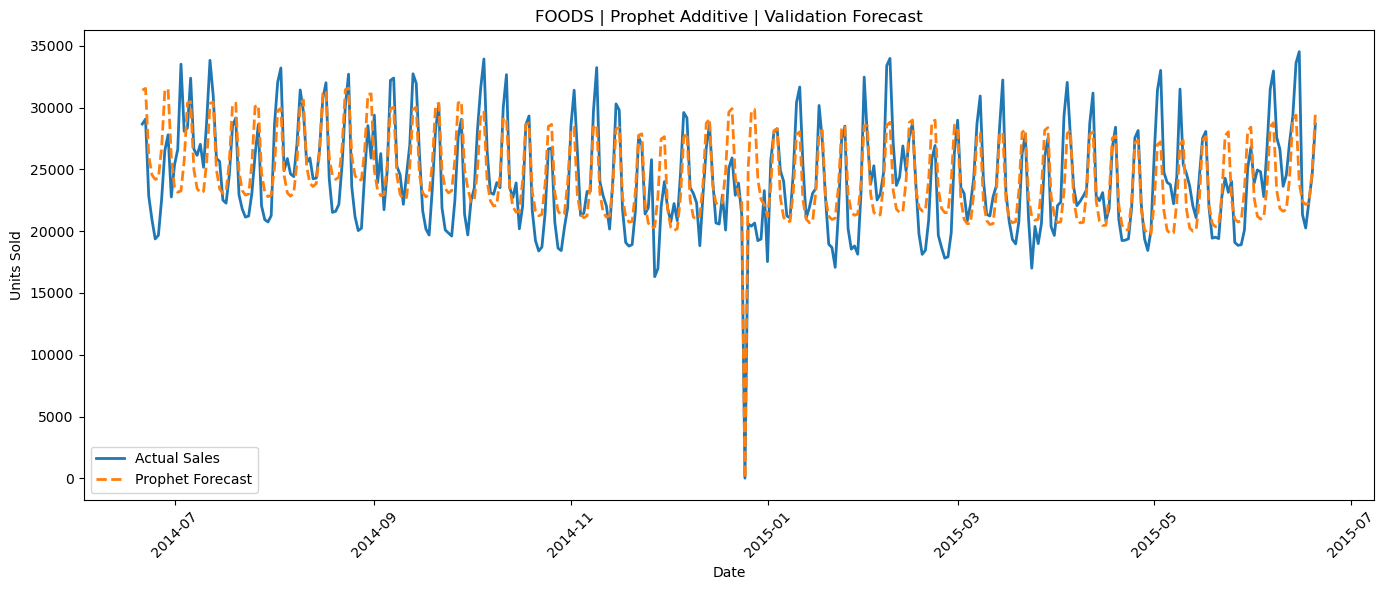

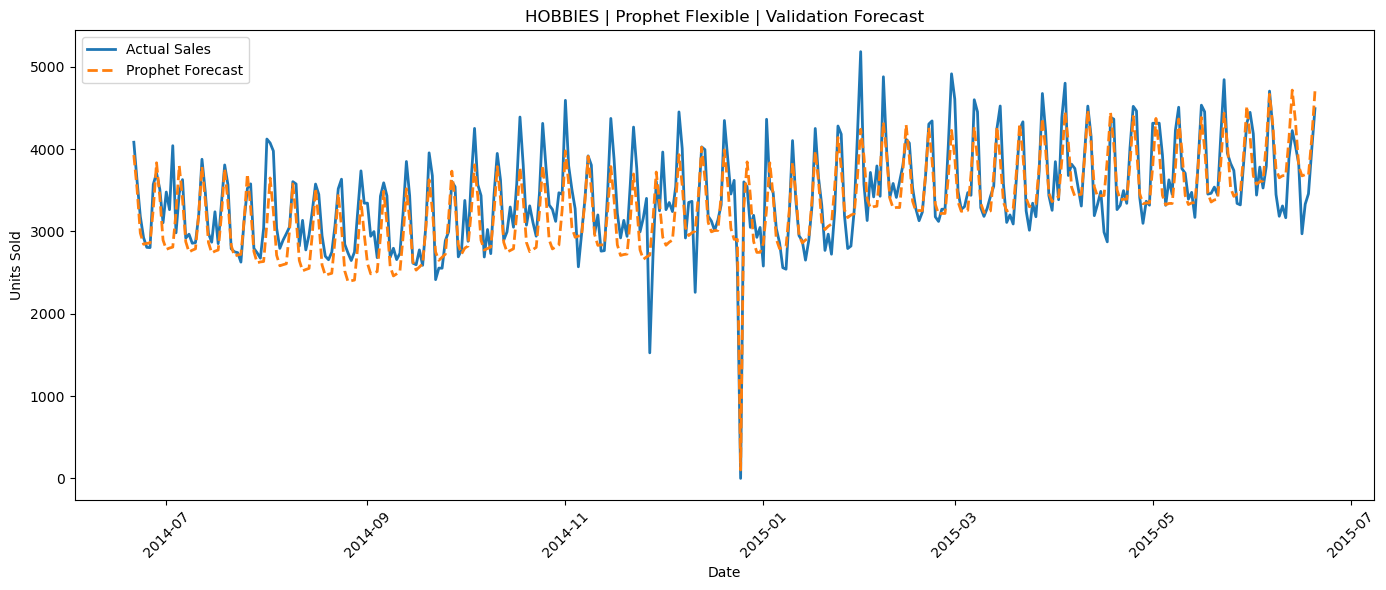

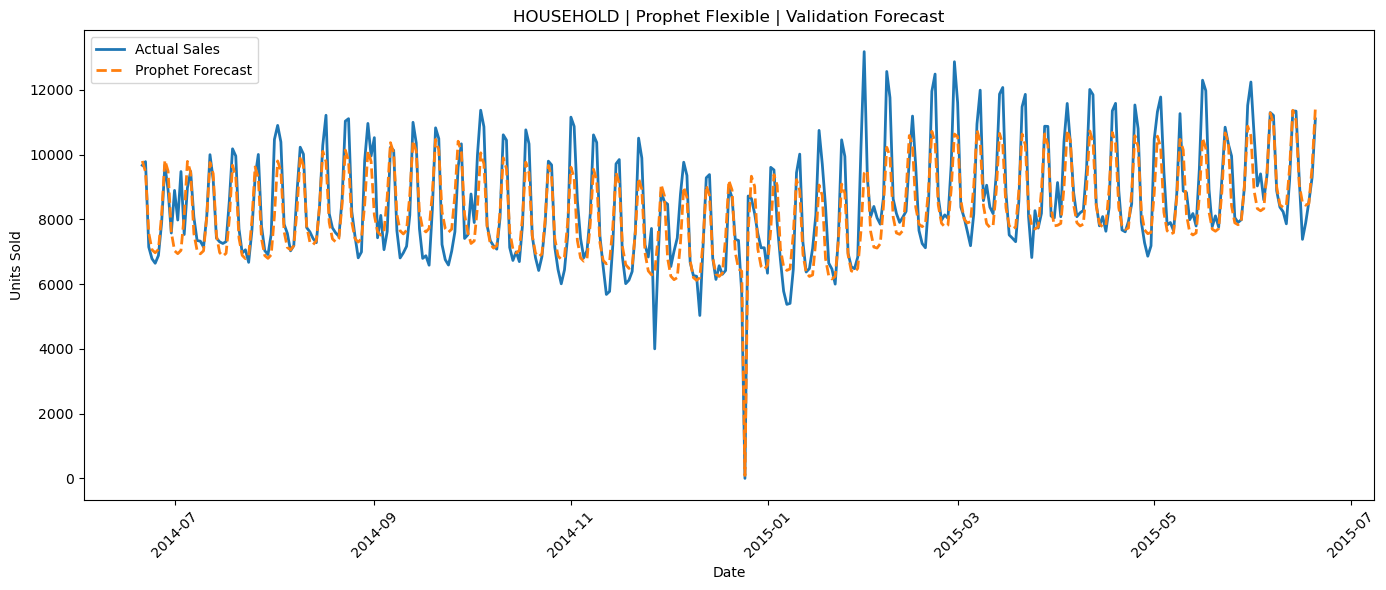

In [19]:
for category in best_prophet_forecasts["cat_id"].unique():

    plot_data = best_prophet_forecasts[
        best_prophet_forecasts["cat_id"] == category
    ]

    model_name = plot_data["Model"].iloc[0]

    plt.figure(figsize=(14, 6))

    plt.plot(
        plot_data["ds"],
        plot_data["actual"],
        label="Actual Sales",
        linewidth=2,
    )

    plt.plot(
        plot_data["ds"],
        plot_data["forecast"],
        label="Prophet Forecast",
        linestyle="--",
        linewidth=2,
    )

    plt.title(
        f"{category} | {model_name} | "
        "Validation Forecast"
    )
    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [20]:
ets_summary = (
    pd.read_parquet(
        "data/processed/rolling_28d_validation_summary.parquet"
    )
    .query("Model == 'ETS'")
)

linear_winners = pd.read_parquet(
    "data/processed/linear_regression_selected_models.parquet"
)

prophet_vs_linear_vs_ets = pd.concat(
    [
        ets_summary,
        linear_winners,
        best_prophet_models,
    ],
    ignore_index=True,
).sort_values(
    ["cat_id", "Mean_WAPE"]
).reset_index(drop=True)

prophet_vs_linear_vs_ets

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Linear Regression (Reduced),1730.43,2187.47,7.08,1.91,4.35,11.76
1,FOODS,Prophet Additive,2226.81,2679.09,9.15,2.53,5.61,15.61
2,FOODS,ETS,2944.02,3502.47,12.09,4.44,8.71,22.36
3,HOBBIES,Linear Regression (Full),223.04,290.39,6.50,1.48,4.73,9.14
4,HOBBIES,Prophet Flexible,250.05,316.36,7.34,2.07,4.09,10.34
5,HOBBIES,ETS,256.19,332.28,7.50,4.03,3.47,18.85
6,HOUSEHOLD,Prophet Flexible,581.16,765.08,6.88,1.99,3.31,10.72
7,HOUSEHOLD,Linear Regression (Full),580.68,751.21,6.91,1.85,4.73,10.33
8,HOUSEHOLD,ETS,629.27,824.15,7.49,2.47,2.52,12.26


In [21]:
current_best_models = (
    prophet_vs_linear_vs_ets
    .sort_values(
        ["cat_id", "Mean_WAPE", "Std_WAPE"]
    )
    .groupby(
        "cat_id",
        observed=True,
    )
    .first()
    .reset_index()
)

current_best_models

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Linear Regression (Reduced),1730.43,2187.47,7.08,1.91,4.35,11.76
1,HOBBIES,Linear Regression (Full),223.04,290.39,6.50,1.48,4.73,9.14
2,HOUSEHOLD,Prophet Flexible,581.16,765.08,6.88,1.99,3.31,10.72


In [22]:
baseline_summary = pd.read_parquet(
    "data/processed/rolling_28d_validation_summary.parquet"
)

linear_summary = pd.read_parquet(
    "data/processed/linear_regression_validation_summary.parquet"
)

all_model_validation_summary = pd.concat(
    [
        baseline_summary,
        linear_summary,
        prophet_tuning_summary,
    ],
    ignore_index=True,
).sort_values(
    ["cat_id", "Mean_WAPE", "Std_WAPE"]
).reset_index(drop=True)

all_model_validation_summary

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Linear Regression (Reduced),1730.43,2187.47,7.08,1.91,4.35,11.76
1,FOODS,Linear Regression (Full),1798.67,2288.85,7.42,1.94,4.81,12.10
2,FOODS,Prophet Additive,2226.81,2679.09,9.15,2.53,5.61,15.61
3,FOODS,Prophet Flexible,2241.65,2691.15,9.21,2.59,5.92,16.12
4,FOODS,Prophet Multiplicative,2259.74,2699.81,9.29,2.92,5.54,17.27
5,FOODS,Prophet Conservative,2276.33,2750.98,9.36,2.44,5.52,15.43
6,FOODS,ETS,2944.02,3502.47,12.09,4.44,8.71,22.36
7,FOODS,Seasonal Naive,3317.54,4054.15,13.64,6.02,9.05,31.00
8,FOODS,7-Day SMA,3592.26,4604.18,14.73,1.85,12.05,18.70
9,FOODS,Naive,4299.83,5299.59,17.70,5.91,12.39,36.02


In [23]:
prophet_setting_table = pd.DataFrame(prophet_settings)

best_prophet_parameters = (
    best_prophet_models[["cat_id", "Model"]]
    .merge(
        prophet_setting_table,
        left_on="Model",
        right_on="name",
    )
    .drop(columns="name")
)

prophet_tuning_metrics.to_parquet(
    "data/processed/prophet_validation_metrics.parquet",
    index=False,
)

prophet_tuning_forecasts.to_parquet(
    "data/processed/prophet_validation_forecasts.parquet",
    index=False,
)

prophet_tuning_summary.to_parquet(
    "data/processed/prophet_validation_summary.parquet",
    index=False,
)

best_prophet_parameters.to_parquet(
    "data/processed/prophet_best_parameters.parquet",
    index=False,
)

all_model_validation_summary.to_parquet(
    "data/processed/all_model_validation_summary.parquet",
    index=False,
)


In [24]:
from pathlib import Path

from prophet.serialize import model_to_json

Path("data/models").mkdir(
    parents=True,
    exist_ok=True,
)

for category in development_daily["cat_id"].unique():

    selected_model_name = best_prophet_models.loc[
        best_prophet_models["cat_id"] == category,
        "Model",
    ].iloc[0]

    selected_setting = next(
        setting
        for setting in prophet_settings
        if setting["name"] == selected_model_name
    )

    category_data = development_daily[
        development_daily["cat_id"] == category
    ].copy()

    final_prophet_model = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        holidays=christmas_holidays,
        seasonality_mode=selected_setting["seasonality_mode"],
        changepoint_prior_scale=selected_setting[
            "changepoint_prior_scale"
        ],
    )

    final_prophet_model.fit(
        category_data[["ds", "y"]]
    )

    with open(
        f"data/models/prophet_pretest_{category}.json",
        "w",
    ) as file:
        file.write(model_to_json(final_prophet_model))

    print(
        f"{category} | {selected_model_name} | "
        f"trained through {category_data['ds'].max().date()}"
    )


02:12:44 - cmdstanpy - INFO - Chain [1] start processing


02:12:44 - cmdstanpy - INFO - Chain [1] done processing


02:12:44 - cmdstanpy - INFO - Chain [1] start processing


02:12:44 - cmdstanpy - INFO - Chain [1] done processing


02:12:44 - cmdstanpy - INFO - Chain [1] start processing


HOBBIES | Prophet Flexible | trained through 2015-06-20
HOUSEHOLD | Prophet Flexible | trained through 2015-06-20


02:12:44 - cmdstanpy - INFO - Chain [1] done processing


FOODS | Prophet Additive | trained through 2015-06-20


## Conclusion

This notebook evaluated four Prophet configurations using the same 13 expanding monthly validation windows as the baseline and Linear Regression notebooks. Weekly and yearly seasonality, together with Christmas as a holiday, were included in every configuration.

| Category | Best Prophet setup | Previous leading model | Previous validation WAPE | Prophet validation WAPE | Improvement vs. previous leader |
|---|---|---|---:|---:|---:|
| FOODS | Additive | Linear Regression (Reduced) | 7.08% | 9.15% | -2.07 percentage points |
| HOBBIES | Flexible | Linear Regression (Full) | 6.50% | 7.34% | -0.84 percentage points |
| HOUSEHOLD | Flexible | Linear Regression (Full) | 6.91% | 6.88% | 0.03 percentage points |

Prophet improved on ETS in every category, but it only improved on the previous leading model for `HOUSEHOLD`. That gain was very small: 0.03 WAPE points. Linear Regression remained the leading validated model for `FOODS` and `HOBBIES`.

The selected Prophet setup for each category was refitted on all training and validation history and saved as a pre-test model. Its results were later included in the XGBoost and final test comparisons.
